In [68]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import re
    
# Read TensorBoard events file using tensorboardX/event accumulator
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

## LSTM

In [69]:
# read all the data
path_data = Path('../logs')

MODEL = 'lstm'

val_mse = []
model_types = []
num_layers = []
hidden_dims = []
bidirectionals = []

# read all the data
for folder in path_data.glob(f'{MODEL}_*'):
    
    name = folder.stem
    
    if (folder / 'version_0').exists():
        # print(folder)
        # get the latest version
        file_versions = folder.glob('version_*')
        latest_version = max(file_versions, key=lambda x: int(x.stem.split('_')[-1]))
        # print(latest_version)
        # break
        folder = latest_version

    events_file = next((folder.glob('events.out.tfevents.*')), None)
    if events_file is not None:
        event_acc = EventAccumulator(str(events_file))
        event_acc.Reload()
        # Example: List all tags
        # print("Available tags:", event_acc.Tags())
        # Example: Get scalar data for a known tag
        for tag in event_acc.Tags().get('scalars', []):
            scalar_events = event_acc.Scalars(tag)
            steps = [e.step for e in scalar_events]
            values = [e.value for e in scalar_events]
            # print(f"Tag: {tag}, Steps: {steps}, Values: {values}")
            
        best_val_mse = min([e.value for e in event_acc.Scalars('step_val_loss_mse')])
    else:
        print(f"No TensorBoard event file found in {folder}")
        best_val_mse = None
        
    model_type = MODEL
    # print(folder.parent.stem)
    # break
    num_layer = int(re.findall(rf'{MODEL}_\d+_.+_(\d+)', name)[0])
    hidden_dim = int(re.findall(rf'{MODEL}_(\d+)_.+_\d+', name)[0])
    bidirectional = re.findall(rf'{MODEL}_\d+_(.+)_', name)[0]
    bidirectional = True if bidirectional == 'true' else False
    
    model_types.append(model_type)
    num_layers.append(num_layer)
    hidden_dims.append(hidden_dim)
    bidirectionals.append(bidirectional)
    
    val_mse.append(best_val_mse)
    
print(len(model_types), len(num_layers), len(hidden_dims), len(bidirectionals), len(val_mse))
data = {
    'model_type': model_types,
    'num_layers': num_layers,
    'hidden_dims': hidden_dims,
    'bidirectionals': bidirectionals,
    'val_mse': val_mse
}

df_lstm = pd.DataFrame(data)
df_lstm

32 32 32 32 32


,model_type,num_layers,hidden_dims,bidirectionals,val_mse
0,lstm,2,64,False,0.361254
1,lstm,4,64,False,0.360772
2,lstm,2,8,False,0.361803
3,lstm,4,128,True,0.360224
4,lstm,4,8,False,0.361594
5,lstm,2,128,True,0.290631
6,lstm,4,64,True,0.361179
7,lstm,2,128,False,0.290841
8,lstm,2,64,True,0.287886
9,lstm,4,128,False,0.361689


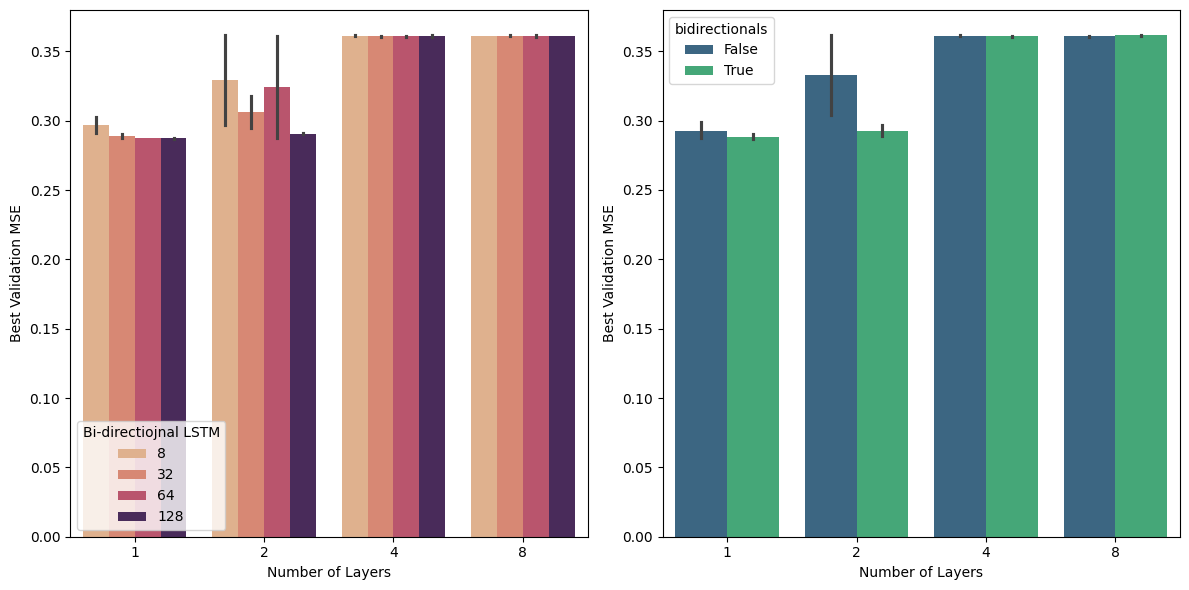

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(x='num_layers', y='val_mse', data=df_lstm, hue='hidden_dims', ax=ax[0], palette='flare')
sns.barplot(x='num_layers', y='val_mse', data=df_lstm, hue='bidirectionals', ax=ax[1], palette='viridis')

for i in range(2):
    ax[i].set_xlabel('Number of Layers')
    ax[i].set_ylabel('Best Validation MSE')
    # ax[i].set_title('Validation MSE vs Number of Layers')
    # ax[i].legend(title='Hidden Dimensions')

ax[0].legend(title='Hidden Dimensions')
ax[0].legend(title='Bi-directiojnal LSTM')

plt.tight_layout()
plt.savefig('plots/lstm_validation_mse_vs_num_layers.png', dpi=300)